# Donut PSF with Vortex Phase Mask

This notebook demonstrates the generation of donut-shaped PSFs using a vortex phase mask, commonly used in STED and MINFLUX microscopy.

## Import Libraries

In [1]:
import math
from psf_generator.propagators import VectorialCartesianPropagator
from psf_generator.utils.plots import plot_pupil, plot_psf

## Vortex Phase Mask

A vortex phase mask imparts an azimuthal phase dependence on the pupil, creating a PSF with zero intensity at the center (donut shape). This is achieved by setting `special_phase_mask='vortex'`.

**Applications:**
- **STED microscopy**: Depletion beam for super-resolution imaging
- **MINFLUX**: Precision localization by positioning emitters at the intensity minimum
- **Optical trapping**: Creating hollow beams

**Note**: Cartesian propagators must be used for arbitrary (non-axisymmetric) phase masks.

In [2]:
kwargs = {
    'n_pix_pupil': 257,
    'n_pix_psf': 256,
    'na': 1.3,
    'wavelength': 600,
    'pix_size': 10,
    'defocus_step': 25,
    'n_defocus': 300,
    'e0x': math.sqrt(2) / 2 * 1j,
    'e0y': math.sqrt(2) / 2,
    'special_phase_mask': 'vortex'
}
propagator = VectorialCartesianPropagator(**kwargs)
psf = propagator.compute_focus_field()
pupil = propagator.get_pupil()

## Visualization

The amplitude visualization clearly shows the donut shape with a central intensity null.

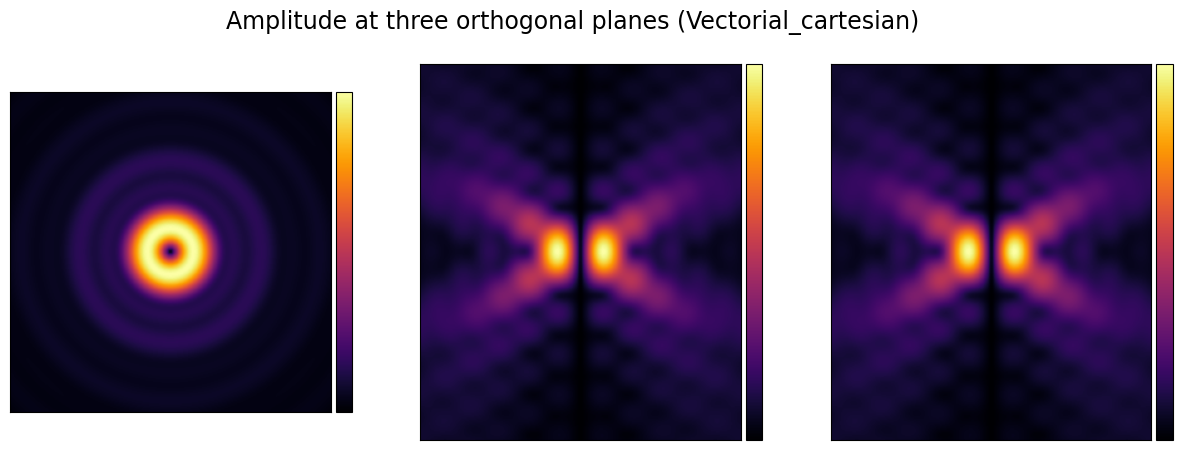

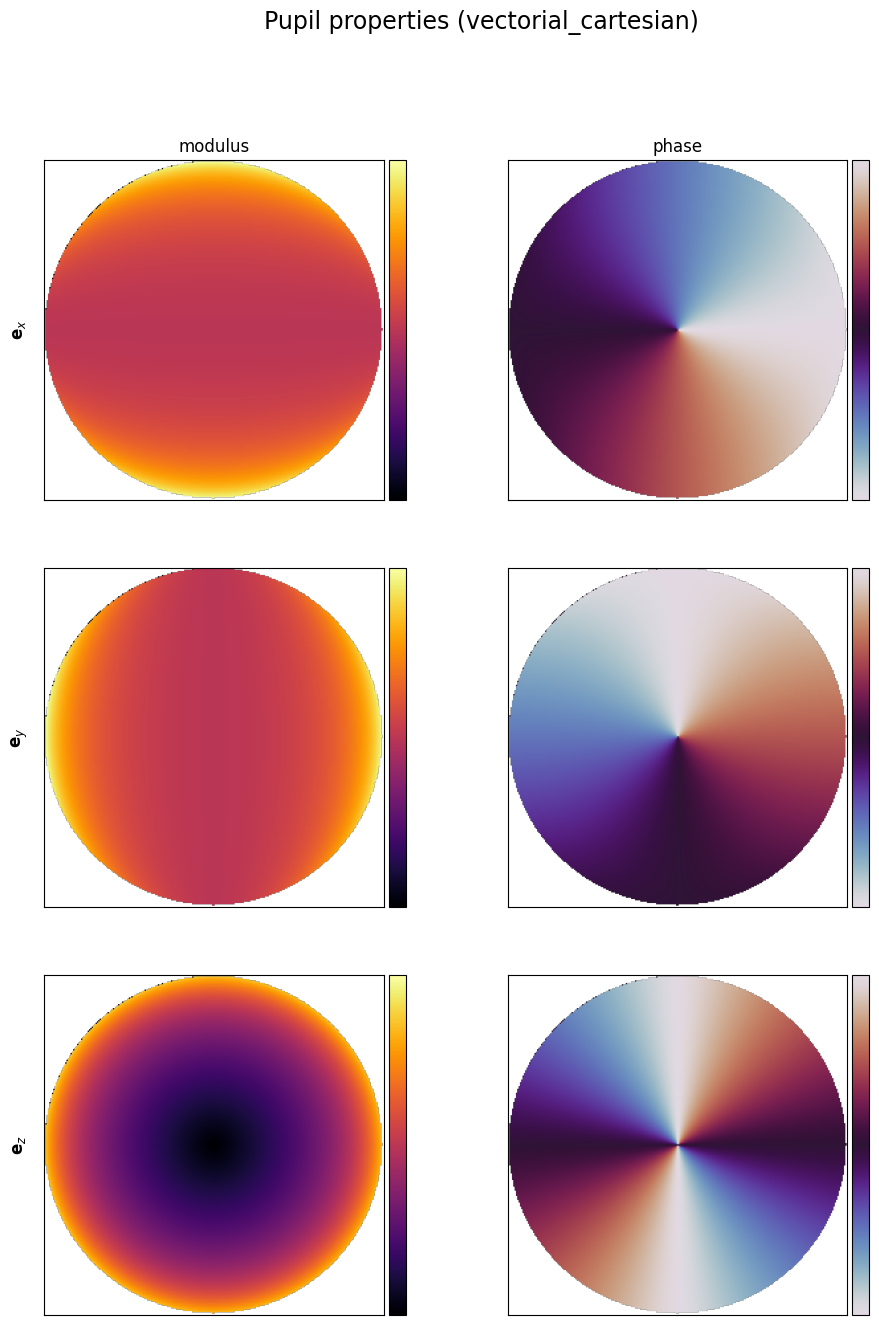

In [3]:
plot_psf(
    psf=psf,
    name_of_propagator=propagator.get_name(),
    quantity='amplitude'
)

plot_pupil(
    pupil,
    name_of_propagator=propagator.get_name()
)

The pupil phase shows the characteristic azimuthal variation of the vortex mask. The PSF exhibits a central null surrounded by a ring of high intensity.

## Troubleshooting

**Phase mask requirements:**
- Vortex masks require Cartesian propagators (spherical propagators assume axial symmetry)
- The `special_phase_mask` parameter accepts: `'vortex'`, `None`, or custom arrays

**Optimizing donut quality:**
- Increase `n_pix_pupil` (257 or 513) for better null depth
- Higher NA produces tighter donuts with better-defined nulls

**Custom phase masks:**
- Provide a 2D array matching pupil dimensions
- Combine with `zernike_coefficients` for additional aberrations

**Polarization effects:**
- Polarization state affects donut shape at high NA
- Experiment with different `e0x` and `e0y` values